<a href="https://colab.research.google.com/github/harshitapaila369-collab/harshu/blob/main/Copy_of_internship_file_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dummy 'retail_sales_dataset.csv' created.
First 5 Rows:
         Date     Category  Sales  Price  Quantity  Discount
0  2023-01-01   Home Goods  240.0  94.86         2      0.02
1  2023-01-02        Books  451.0  63.90         2      0.01
2  2023-01-03  Electronics  267.0  72.53         2      0.11
3  2023-01-04   Home Goods   93.0  89.24         6      0.11
4  2023-01-05   Home Goods  211.0  66.19         3      0.13

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Date      100 non-null    object 
 1   Category  99 non-null     object 
 2   Sales     99 non-null     float64
 3   Price     99 non-null     float64
 4   Quantity  100 non-null    int64  
 5   Discount  100 non-null    float64
dtypes: float64(3), int64(1), object(2)
memory usage: 4.8+ KB
None

Missing Values:
Date        0
Category    1
Sales       1
Price       1
Q

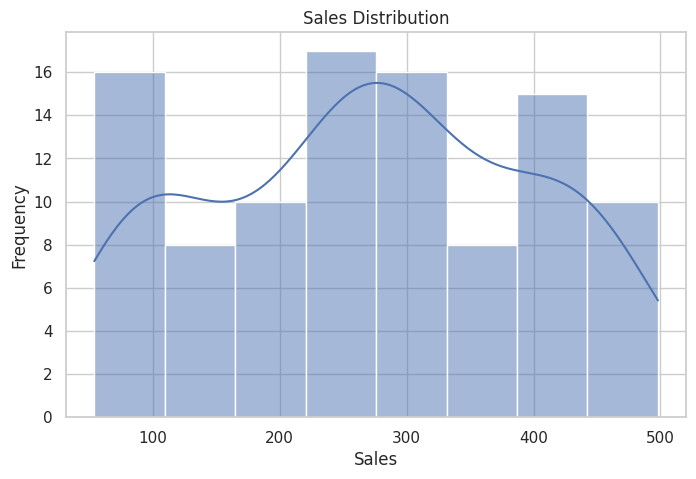

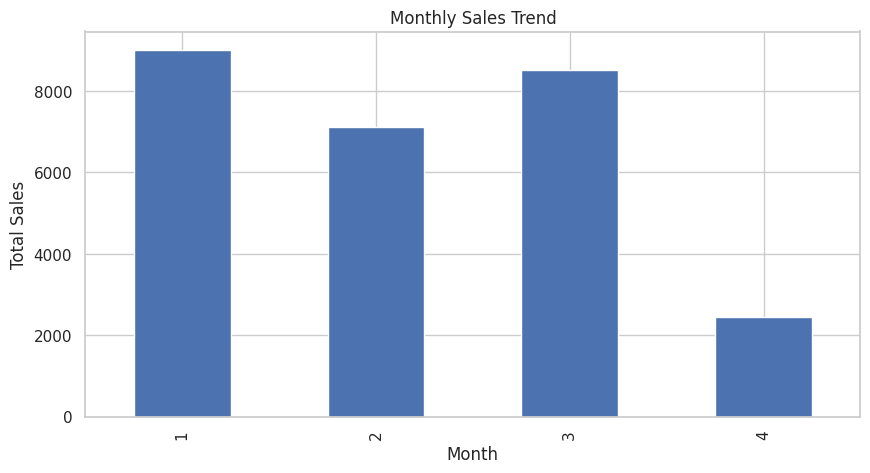

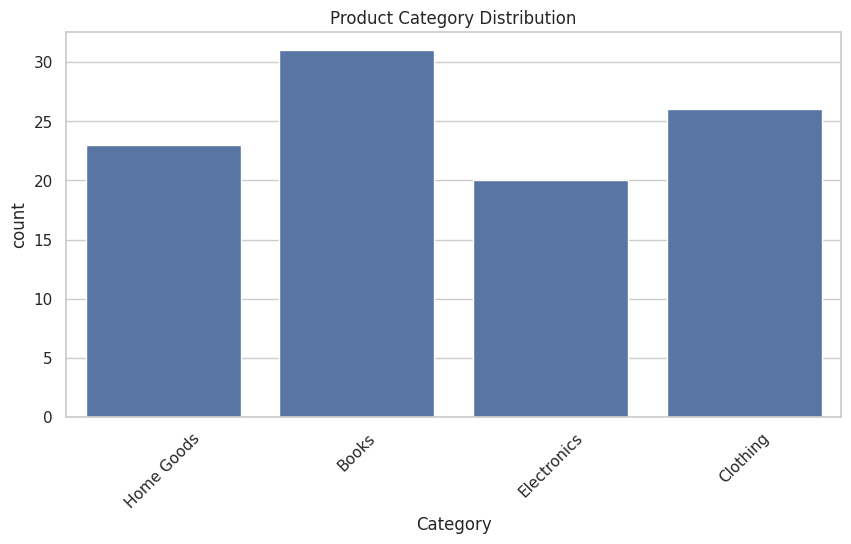

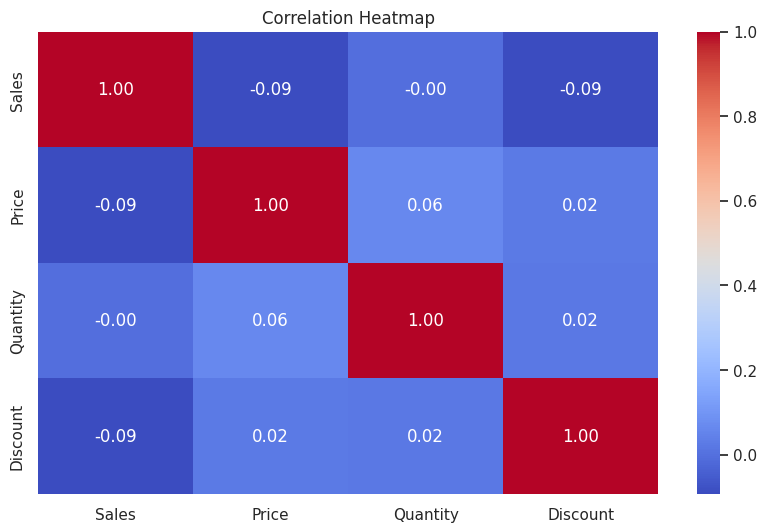

DTypePromotionError: The DType <class 'numpy.dtypes.DateTime64DType'> could not be promoted by <class 'numpy.dtypes.Float64DType'>. This means that no common DType exists for the given inputs. For example they cannot be stored in a single array unless the dtype is `object`. The full list of DTypes is: (<class 'numpy.dtypes.DateTime64DType'>, <class 'numpy.dtypes.Float64DType'>, <class 'numpy.dtypes.Int64DType'>, <class 'numpy.dtypes.Float64DType'>, <class 'numpy.dtypes.Int32DType'>, <class 'numpy.dtypes.BoolDType'>, <class 'numpy.dtypes.BoolDType'>, <class 'numpy.dtypes.BoolDType'>)

In [ ]:
# =========================================================
# Real-World Data Project (Retail Sales Analysis)
# =========================================================

# Project:
# Sales Prediction and Analysis using Retail Dataset

# =========================================================
# Import Required Libraries
# =========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning Libraries
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# =========================================================
# Step 1: Load Dataset
# =========================================================

# Create a dummy CSV file for demonstration purposes to avoid FileNotFoundError
# If you have your own 'retail_sales_dataset.csv', you can upload it to Colab
# or update the path in pd.read_csv() below.
np.random.seed(42) # for reproducibility
dates = pd.to_datetime(pd.date_range(start='2023-01-01', periods=100, freq='D'))
categories = ['Electronics', 'Clothing', 'Home Goods', 'Books']
data_dummy = pd.DataFrame({
    'Date': dates,
    'Category': np.random.choice(categories, 100),
    'Sales': np.random.randint(50, 500, 100),
    'Price': np.random.uniform(10, 100, 100).round(2),
    'Quantity': np.random.randint(1, 10, 100),
    'Discount': np.random.uniform(0, 0.2, 100).round(2)
})

# Add some missing values for testing data cleaning steps
data_dummy.loc[5, 'Sales'] = np.nan
data_dummy.loc[10, 'Category'] = np.nan
data_dummy.loc[15, 'Price'] = np.nan

data_dummy.to_csv("retail_sales_dataset.csv", index=False)

print("Dummy 'retail_sales_dataset.csv' created.")

# Replace with your dataset file
data = pd.read_csv("retail_sales_dataset.csv")

# Display first 5 rows
print("First 5 Rows:")
print(data.head())

# =========================================================
# Step 2: Dataset Information
# =========================================================

print("\nDataset Information:")
print(data.info())

print("\nMissing Values:")
print(data.isnull().sum())

# =========================================================
# Step 3: Handle Missing Values
# =========================================================

# Fill numeric missing values with mean
numeric_columns = data.select_dtypes(include=np.number).columns

for column in numeric_columns:
    data[column] = data[column].fillna(data[column].mean())

# Fill categorical missing values with mode
categorical_columns = data.select_dtypes(include='object').columns

for column in categorical_columns:
    data[column] = data[column].fillna(data[column].mode()[0])

# =========================================================
# Step 4: Remove Duplicate Rows
# =========================================================

print("\nDuplicate Rows:", data.duplicated().sum())

data.drop_duplicates(inplace=True)

# =========================================================
# Step 5: Data Visualization
# =========================================================

sns.set(style="whitegrid")

# ---------------------------------------------------------
# 1. Sales Distribution
# ---------------------------------------------------------

plt.figure(figsize=(8,5))

sns.histplot(data['Sales'], kde=True)

plt.title("Sales Distribution")
plt.xlabel("Sales")
plt.ylabel("Frequency")

plt.show()

# ---------------------------------------------------------
# 2. Monthly Sales Trend
# ---------------------------------------------------------

# Convert date column
data['Date'] = pd.to_datetime(data['Date'])

data['Month'] = data['Date'].dt.month

monthly_sales = data.groupby('Month')['Sales'].sum()

plt.figure(figsize=(10,5))

monthly_sales.plot(kind='bar')

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")

plt.show()

# ---------------------------------------------------------
# 3. Product Category Analysis
# ---------------------------------------------------------

plt.figure(figsize=(10,5))

sns.countplot(x='Category', data=data)

plt.title("Product Category Distribution")

plt.xticks(rotation=45)

plt.show()

# ---------------------------------------------------------
# 4. Correlation Heatmap
# ---------------------------------------------------------

plt.figure(figsize=(10,6))

correlation = data[numeric_columns].corr()

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

# =========================================================
# Step 6: Prepare Data for Prediction
# =========================================================

# Convert categorical columns using one-hot encoding
data = pd.get_dummies(data, drop_first=True)

# =========================================================
# Step 7: Feature Selection
# =========================================================

# Assume 'Sales' is target variable
X = data.drop('Sales', axis=1)
y = data['Sales']

# =========================================================
# Step 8: Train-Test Split
# =========================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# =========================================================
# Step 9: Train Linear Regression Model
# =========================================================

model = LinearRegression()

model.fit(X_train, y_train)

# =========================================================
# Step 10: Predictions
# =========================================================

predictions = model.predict(X_test)

# =========================================================
# Step 11: Model Evaluation
# =========================================================

mae = mean_absolute_error(y_test, predictions)
mse = mean_squared_error(y_test, predictions)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, predictions)

print("\nModel Evaluation Metrics:")

print("Mean Absolute Error:", mae)
print("Mean Squared Error:", mse)
print("Root Mean Squared Error:", rmse)
print("R2 Score:", r2)

# =========================================================
# Step 12: Actual vs Predicted Visualization
# =========================================================

plt.figure(figsize=(8,5))

plt.scatter(y_test, predictions)

plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")

plt.title("Actual vs Predicted Sales")

plt.show()

# =========================================================
# Step 13: Feature Importance
# =========================================================

coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
})

print("\nFeature Importance:")
print(coefficients.sort_values(by='Coefficient', ascending=False))

# =========================================================
# Step 14: Save Predictions
# =========================================================

results = pd.DataFrame({
    'Actual Sales': y_test,
    'Predicted Sales': predictions
})

results.to_csv("sales_predictions.csv", index=False)

print("\nPredictions Saved Successfully!")

# =========================================================
# Step 15: Final Insights
# =========================================================

print("""
=========================================================
Final Conclusion
=========================================================

1. Missing values and duplicates were handled successfully.
2. Monthly sales trends were identified.
3. Product categories with high sales were analyzed.
4. Correlation between variables was visualized.
5. Linear Regression model was trained for sales prediction.
6. Predicted sales values were compared with actual values.
7. Real-world retail business insights were generated.

=========================================================
Project Completed Successfully!
=========================================================
""")

In [ ]:
# @title AI prompt cell

import ipywidgets as widgets
from IPython.display import display, HTML, Markdown,clear_output
from google.colab import ai

dropdown = widgets.Dropdown(
    options=[],
    layout={'width': 'auto'}
)

def update_model_list(new_options):
    dropdown.options = new_options
update_model_list(ai.list_models())

text_input = widgets.Textarea(
    placeholder='Ask me anything....',
    layout={'width': 'auto', 'height': '100px'},
)

button = widgets.Button(
    description='Submit Text',
    disabled=False,
    tooltip='Click to submit the text',
    icon='check'
)

output_area = widgets.Output(
     layout={'width': 'auto', 'max_height': '300px','overflow_y': 'scroll'}
)

def on_button_clicked(b):
    with output_area:
        output_area.clear_output(wait=False)
        accumulated_content = ""
        for new_chunk in ai.generate_text(prompt=text_input.value, model_name=dropdown.value, stream=True):
            if new_chunk is None:
                continue
            accumulated_content += new_chunk
            clear_output(wait=True)
            display(Markdown(accumulated_content))

button.on_click(on_button_clicked)
vbox = widgets.GridBox([dropdown, text_input, button, output_area])

display(HTML("""
<style>
.widget-dropdown select {
    font-size: 18px;
    font-family: "Arial", sans-serif;
}
.widget-textarea textarea {
    font-size: 18px;
    font-family: "Arial", sans-serif;
}
</style>
"""))
display(vbox)


GridBox(children=(Dropdown(layout=Layout(width='auto'), options=('google/gemini-2.5-flash', 'google/gemini-2.5…

Dummy 'stock_data.csv' created.
First 5 Rows:
         Date    Open    High     Low   Close     Volume
0  2020-01-01  137.45  142.33  136.21  140.97  3768408.0
1  2020-01-02  195.07  195.40  192.17  193.24  1186833.0
2  2020-01-03  173.20  175.02  168.11  169.89  1717912.0
3  2020-01-06  159.87  162.08  158.29  160.43  1775435.0
4  2020-01-07  115.60  121.86  115.30  119.96  3174606.0

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 252 entries, 0 to 251
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    252 non-null    object 
 1   Open    252 non-null    float64
 2   High    252 non-null    float64
 3   Low     252 non-null    float64
 4   Close   251 non-null    float64
 5   Volume  251 non-null    float64
dtypes: float64(5), object(1)
memory usage: 11.9+ KB
None

Missing Values:
Date      0
Open      0
High      0
Low       0
Close     1
Volume    1
dtype: int64


/tmp/ipykernel_3307/1762993107.py:84: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data[column].fillna(data[column].mean(), inplace=True)


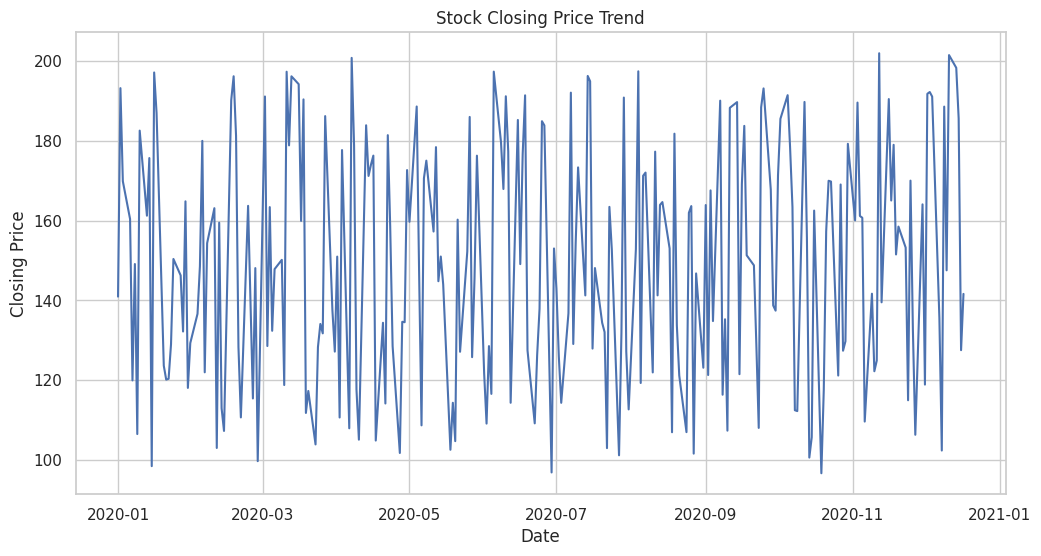

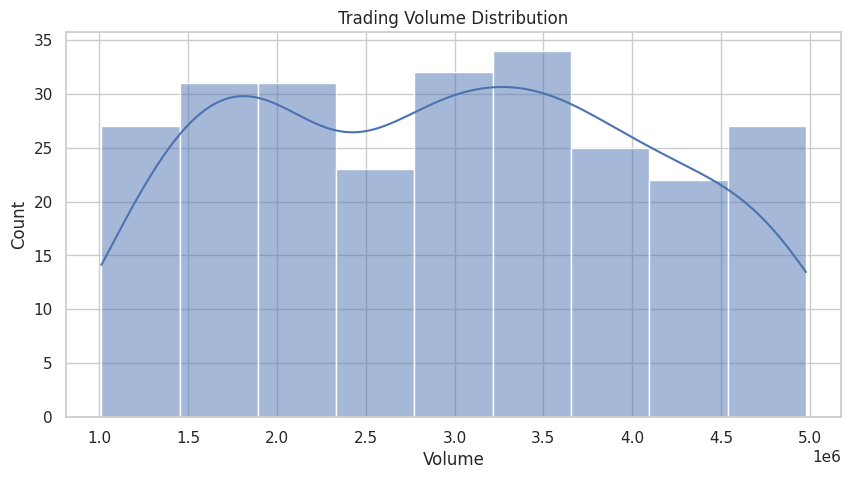

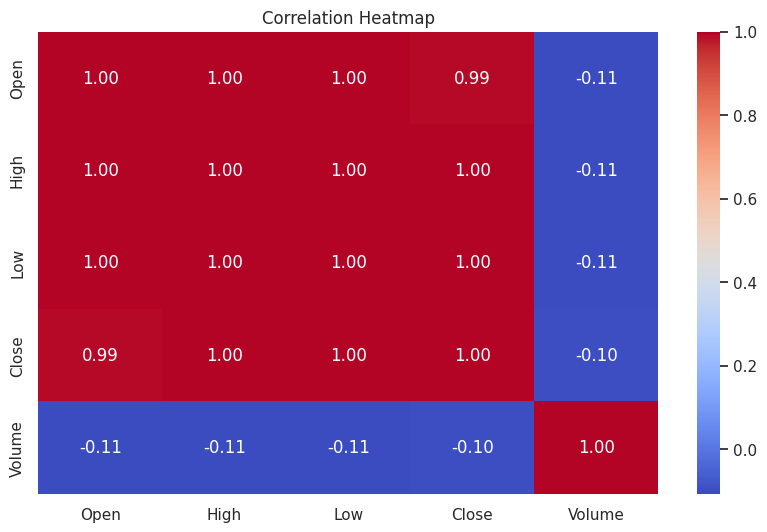


Model Evaluation Metrics
Mean Absolute Error: 0.693152017011285
Mean Squared Error: 0.6426664576485395
Root Mean Squared Error: 0.8016648037980334
R2 Score: 0.999310471043974


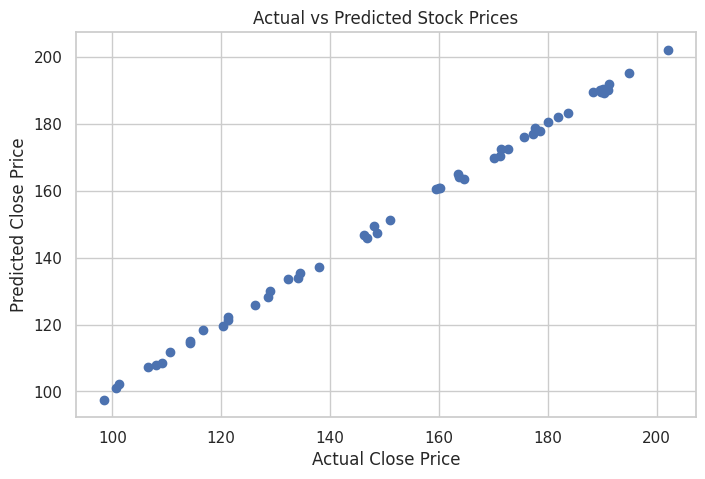


Feature Importance:
  Feature   Coefficient
0    Open -8.912847e-01
1    High  9.180613e-01
2     Low  9.714604e-01
3  Volume  1.872379e-07

Prediction Results Saved Successfully!

FINAL REPORT

1. Stock market dataset was analyzed successfully.
2. Missing values were handled properly.
3. Trends in stock closing prices were visualized.
4. Correlations among stock variables were identified.
5. Linear Regression model was used for prediction.
6. Actual and predicted prices were compared visually.
7. The project demonstrated real-world financial analysis
   using Data Science and Machine Learning.

PROJECT COMPLETED SUCCESSFULLY



In [ ]:
# =========================================================
# REAL-WORLD DATA PROJECT
# Domain: Finance (Stock Market Analysis & Prediction)
# =========================================================

# Project Objective:
# Analyze stock market data and predict future stock prices
# using Machine Learning techniques.

# =========================================================
# Import Required Libraries
# =========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning Libraries
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# =========================================================
# Step 1: Load Dataset
# =========================================================

# Create a dummy CSV file for demonstration purposes to avoid FileNotFoundError
# If you have your own 'stock_data.csv', you can upload it to Colab
# or update the path in pd.read_csv() below.
np.random.seed(42) # for reproducibility
dates_stock = pd.to_datetime(pd.date_range(start='2020-01-01', periods=252, freq='B')) # Business days for a year
open_prices = np.random.uniform(100, 200, 252)
close_prices = open_prices + np.random.uniform(-5, 5, 252)
high_prices = np.maximum(open_prices, close_prices) + np.random.uniform(0, 2, 252)
low_prices = np.minimum(open_prices, close_prices) - np.random.uniform(0, 2, 252)
volumes = np.random.randint(1000000, 5000000, 252)

data_stock_dummy = pd.DataFrame({
    'Date': dates_stock,
    'Open': open_prices.round(2),
    'High': high_prices.round(2),
    'Low': low_prices.round(2),
    'Close': close_prices.round(2),
    'Volume': volumes
})

# Add some missing values for testing data cleaning steps
data_stock_dummy.loc[5, 'Close'] = np.nan
data_stock_dummy.loc[10, 'Volume'] = np.nan

data_stock_dummy.to_csv("stock_data.csv", index=False)

print("Dummy 'stock_data.csv' created.")

# Replace with your stock dataset file
data = pd.read_csv("stock_data.csv")

# Display dataset
print("First 5 Rows:")
print(data.head())

# =========================================================
# Step 2: Dataset Information
# =========================================================

print("\nDataset Information:")
print(data.info())

print("\nMissing Values:")
print(data.isnull().sum())

# =========================================================
# Step 3: Handle Missing Values
# =========================================================

numeric_columns = data.select_dtypes(include=np.number).columns

for column in numeric_columns:
    data[column] = data[column].fillna(data[column].mean())

# =========================================================
# Step 4: Convert Date Column
# =========================================================

data['Date'] = pd.to_datetime(data['Date'])

# =========================================================
# Step 5: Exploratory Data Analysis
# =========================================================

sns.set(style="whitegrid")

# ---------------------------------------------------------
# 1. Closing Price Trend
# ---------------------------------------------------------

plt.figure(figsize=(12,6))

plt.plot(data['Date'], data['Close'])

plt.title("Stock Closing Price Trend")
plt.xlabel("Date")
plt.ylabel("Closing Price")

plt.show()

# ---------------------------------------------------------
# 2. Trading Volume Analysis
# ---------------------------------------------------------

plt.figure(figsize=(10,5))

sns.histplot(data['Volume'], kde=True)

plt.title("Trading Volume Distribution")
plt.xlabel("Volume")

plt.show()

# ---------------------------------------------------------
# 3. Correlation Heatmap
# ---------------------------------------------------------

plt.figure(figsize=(10,6))

correlation = data[numeric_columns].corr()

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

# =========================================================
# Step 6: Feature Selection
# =========================================================

# Using stock features to predict closing price

X = data[['Open', 'High', 'Low', 'Volume']]
y = data['Close']

# =========================================================
# Step 7: Train-Test Split
# =========================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# =========================================================
# Step 8: Train Machine Learning Model
# =========================================================

model = LinearRegression()

model.fit(X_train, y_train)

# =========================================================
# Step 9: Predictions
# =========================================================

predictions = model.predict(X_test)

# =========================================================
# Step 10: Model Evaluation
# =========================================================

mae = mean_absolute_error(y_test, predictions)
mse = mean_squared_error(y_test, predictions)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, predictions)

print("\nModel Evaluation Metrics")

print("Mean Absolute Error:", mae)
print("Mean Squared Error:", mse)
print("Root Mean Squared Error:", rmse)
print("R2 Score:", r2)

# =========================================================
# Step 11: Actual vs Predicted Prices
# =========================================================

plt.figure(figsize=(8,5))

plt.scatter(y_test, predictions)

plt.xlabel("Actual Close Price")
plt.ylabel("Predicted Close Price")

plt.title("Actual vs Predicted Stock Prices")

plt.show()

# =========================================================
# Step 12: Feature Importance
# =========================================================

importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
})

print("\nFeature Importance:")
print(importance)

# =========================================================
# Step 13: Save Prediction Results
# =========================================================

results = pd.DataFrame({
    'Actual Price': y_test,
    'Predicted Price': predictions
})

results.to_csv("stock_price_predictions.csv", index=False)

print("\nPrediction Results Saved Successfully!")

# =========================================================
# Step 14: Final Conclusion
# =========================================================

print("""
=========================================================
FINAL REPORT
=========================================================

1. Stock market dataset was analyzed successfully.
2. Missing values were handled properly.
3. Trends in stock closing prices were visualized.
4. Correlations among stock variables were identified.
5. Linear Regression model was used for prediction.
6. Actual and predicted prices were compared visually.
7. The project demonstrated real-world financial analysis
   using Data Science and Machine Learning.

=========================================================
PROJECT COMPLETED SUCCESSFULLY
=========================================================
""")